# RNN 시계열 데이터 시각화
### 핵심 개념: 연속된 시계열 데이터 → RNN의 시퀀스(Sequence) 데이터
- 시계열(Time Series): 시간 순서대로 나열된 데이터
- 시퀀스(Sequence): 순서가 의미 있는 데이터 → RNN의 입력 형태
- **슬라이딩 윈도우(Sliding Window)** 로 시계열을 시퀀스로 변환

/tmp/ipykernel_20229/2430894333.py:20: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_20229/2430894333.py:20: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_20229/2430894333.py:20: UserWarning: Glyph 50676 (\N{HANGUL SYLLABLE YEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_20229/2430894333.py:20: UserWarning: Glyph 45936 (\N{HANGUL SYLLABLE DE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_20229/2430894333.py:20: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_20229/2430894333.py:20: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_20229/2430894333.py:20: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.ti

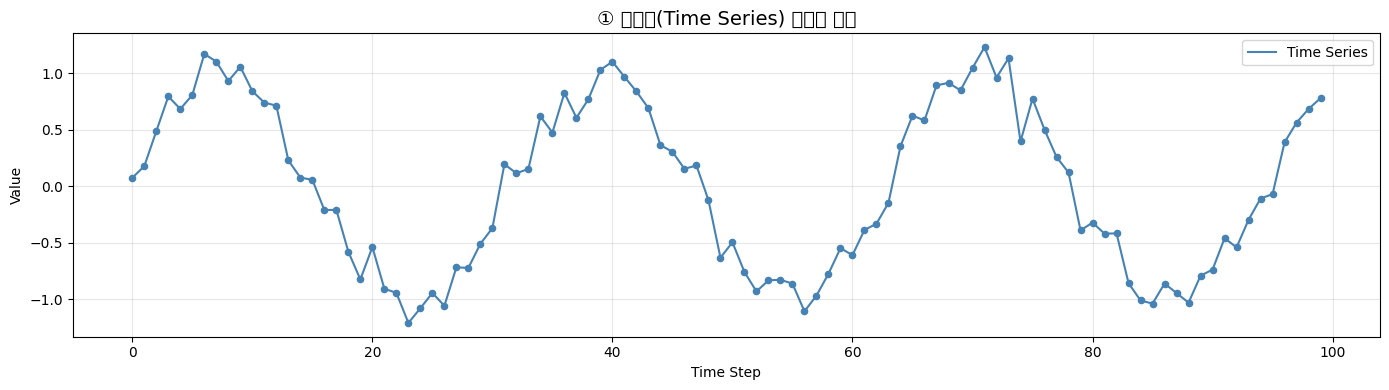

시계열 데이터 shape: (100,)  → (타임스텝 수,)


In [48]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

# ── 1. 시계열 데이터 생성 (사인파 + 노이즈) ──
np.random.seed(42)
t = np.arange(0, 100)                          # 시간 축 (0~99)
time_series = np.sin(t * 0.2) + np.random.normal(0, 0.15, size=len(t))

# ── 2. 전체 시계열 시각화 ──
plt.figure(figsize=(14, 4))
plt.plot(t, time_series, color='steelblue', linewidth=1.5, label='Time Series')
plt.scatter(t, time_series, color='steelblue', s=20, zorder=5)
plt.title('① 시계열(Time Series) 데이터 전체', fontsize=14)
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"시계열 데이터 shape: {time_series.shape}  → (타임스텝 수,)")

/tmp/ipykernel_20229/1538810321.py:27: UserWarning: Glyph 49836 (\N{HANGUL SYLLABLE SEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_20229/1538810321.py:27: UserWarning: Glyph 46972 (\N{HANGUL SYLLABLE RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_20229/1538810321.py:27: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_20229/1538810321.py:27: UserWarning: Glyph 46377 (\N{HANGUL SYLLABLE DING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_20229/1538810321.py:27: UserWarning: Glyph 50952 (\N{HANGUL SYLLABLE WIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_20229/1538810321.py:27: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_20229/1538810321.py:27: UserWarning: Glyph 50864 (\N{HANGUL SYLLABLE U}) missing from font(s) DejaVu Sans.
  plt.tigh

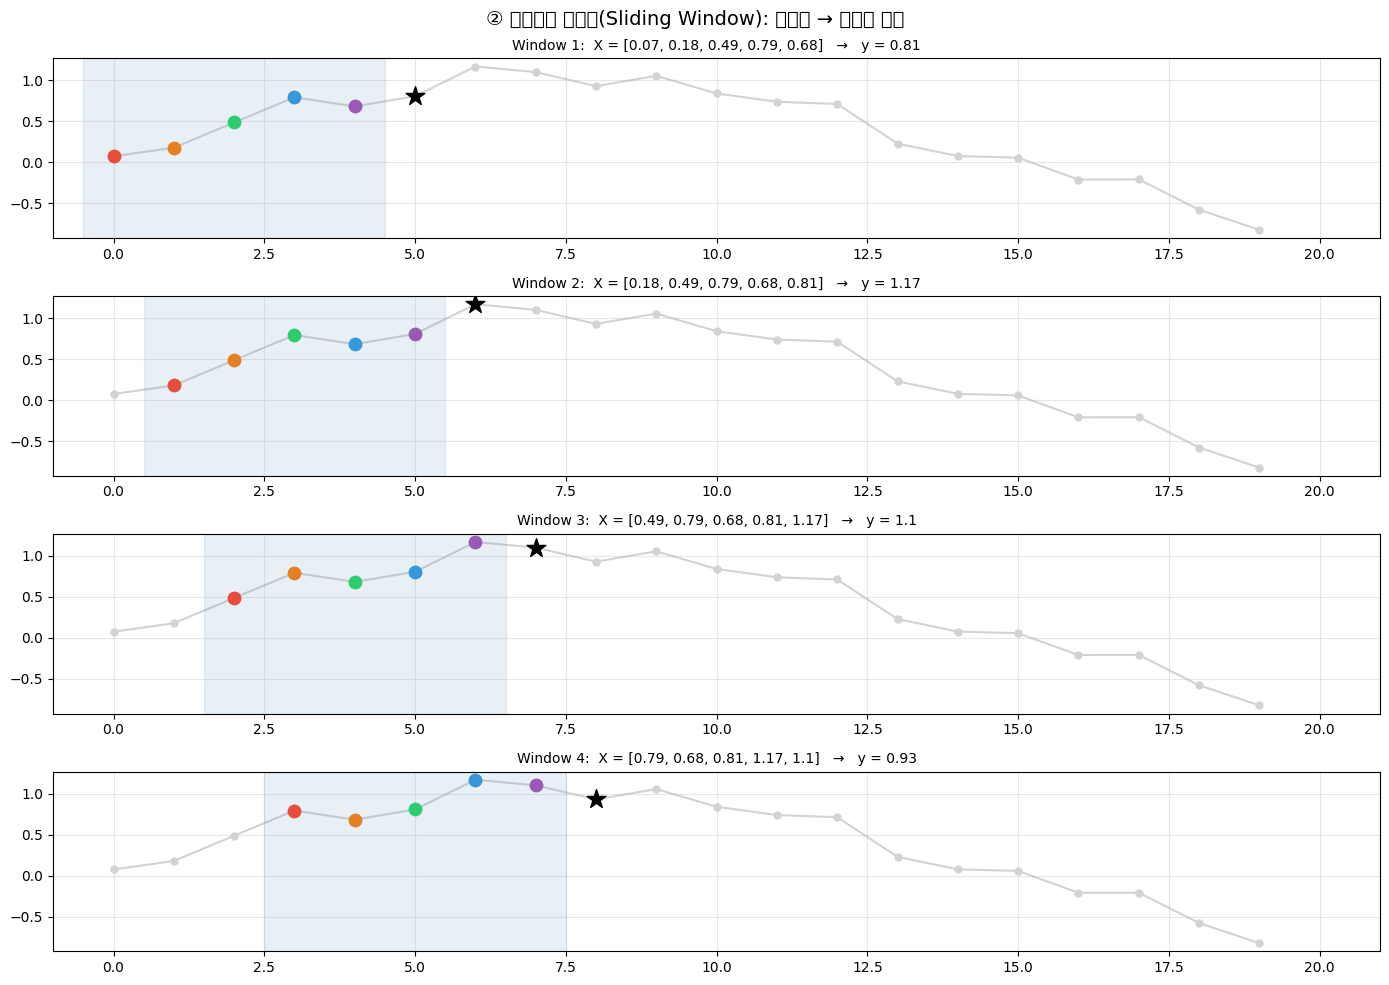

In [49]:
# ── 3. 슬라이딩 윈도우로 시퀀스 데이터 변환 과정 시각화 ──
window_size = 5   # 입력 시퀀스 길이 (과거 5개 → 다음 1개 예측)
colors = ['#e74c3c', '#e67e22', '#2ecc71', '#3498db', '#9b59b6']

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
fig.suptitle('② 슬라이딩 윈도우(Sliding Window): 시계열 → 시퀀스 변환', fontsize=14)

show_steps = 4   # 윈도우 4개 예시
for i, ax in enumerate(axes):
    ax.plot(t[:20], time_series[:20], color='lightgray', linewidth=1.5, zorder=1)
    ax.scatter(t[:20], time_series[:20], color='lightgray', s=25, zorder=2)

    # 윈도우 구간 색칠
    for j in range(window_size):
        ax.scatter(t[i+j], time_series[i+j], color=colors[j], s=80, zorder=5)
    # 예측 타깃
    ax.scatter(t[i+window_size], time_series[i+window_size],
               marker='*', color='black', s=200, zorder=6, label=f'Target (t+{window_size})')

    # 윈도우 박스
    ax.axvspan(t[i]-0.5, t[i+window_size-1]+0.5, alpha=0.12, color='steelblue')
    ax.set_title(f'Window {i+1}:  X = {[round(time_series[i+j],2) for j in range(window_size)]}   →   y = {round(time_series[i+window_size],2)}',
                 fontsize=10)
    ax.set_xlim(-1, 21)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [50]:
# ── 4. 실제 X, y 시퀀스 데이터셋 생성 ──
def make_sequence_dataset(series, window):
    X, y = [], []
    for i in range(len(series) - window):
        X.append(series[i:i+window])   # 입력: 과거 window개
        y.append(series[i+window])     # 정답: 다음 1개
    return np.array(X), np.array(y)

window_size = 5
X, y = make_sequence_dataset(time_series, window_size)

print("=" * 50)
print(f"원본 시계열 shape  : {time_series.shape}")
print(f"X (입력 시퀀스) shape: {X.shape}  → (샘플 수, 시퀀스 길이)")
print(f"y (예측 타깃)   shape: {y.shape}  → (샘플 수,)")
print("=" * 50)
print(f"\n첫 번째 샘플 X[0]: {np.round(X[0], 3)}  →  y[0]: {round(y[0], 3)}")
print(f"두 번째 샘플 X[1]: {np.round(X[1], 3)}  →  y[1]: {round(y[1], 3)}")

# DataFrame으로 확인
df_seq = pd.DataFrame(X, columns=[f't-{window_size-i}' for i in range(window_size)])
df_seq['y(target)'] = y
print("\n시퀀스 데이터셋 (처음 5행):")
print(df_seq.head().round(3))

원본 시계열 shape  : (100,)
X (입력 시퀀스) shape: (95, 5)  → (샘플 수, 시퀀스 길이)
y (예측 타깃)   shape: (95,)  → (샘플 수,)

첫 번째 샘플 X[0]: [0.075 0.178 0.487 0.793 0.682]  →  y[0]: 0.806
두 번째 샘플 X[1]: [0.178 0.487 0.793 0.682 0.806]  →  y[1]: 1.169

시퀀스 데이터셋 (처음 5행):
     t-5    t-4    t-3    t-2    t-1  y(target)
0  0.075  0.178  0.487  0.793  0.682      0.806
1  0.178  0.487  0.793  0.682  0.806      1.169
2  0.487  0.793  0.682  0.806  1.169      1.101
3  0.793  0.682  0.806  1.169  1.101      0.929
4  0.682  0.806  1.169  1.101  0.929      1.055


  RNN 입력 Shape 변환
  X (2D):     (95, 5)       → (샘플수, 시퀀스길이)
  X_rnn (3D): (95, 5, 1)  → (샘플수, 시퀀스길이, 피처수)


/tmp/ipykernel_20229/3776931887.py:38: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_20229/3776931887.py:38: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_20229/3776931887.py:38: UserWarning: Glyph 50676 (\N{HANGUL SYLLABLE YEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_20229/3776931887.py:38: UserWarning: Glyph 53248 (\N{HANGUL SYLLABLE KWEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_20229/3776931887.py:38: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_20229/3776931887.py:38: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_20229/3776931887.py:38: UserWarning: Glyph 47141 (\N{HANGUL SYLLABLE RYEOG}) missing from font(s) DejaVu Sans.
  p

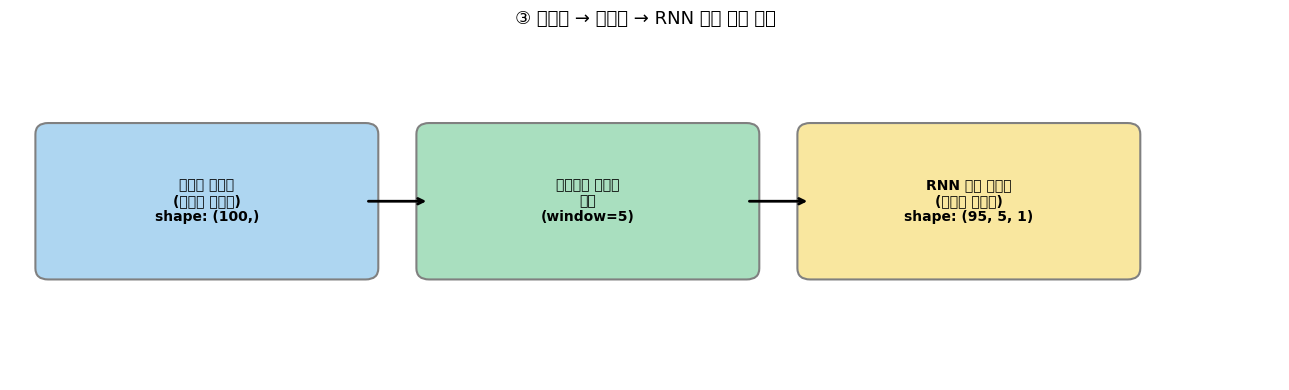


✅ 핵심 정리
  시계열 데이터는 '순서가 중요한 연속 데이터' = 시퀀스 데이터
  슬라이딩 윈도우로 (X: 과거 N개, y: 다음 1개) 쌍을 만들어 RNN에 입력


In [51]:
# ── 5. RNN 입력 shape 변환 및 최종 정리 ──
# RNN은 3D 입력을 요구: (batch_size, timesteps, features)
X_rnn = X.reshape(X.shape[0], X.shape[1], 1)

print("=" * 55)
print("  RNN 입력 Shape 변환")
print("=" * 55)
print(f"  X (2D):     {X.shape}       → (샘플수, 시퀀스길이)")
print(f"  X_rnn (3D): {X_rnn.shape}  → (샘플수, 시퀀스길이, 피처수)")
print("=" * 55)

# ── 최종 개념 정리 시각화 ──
fig, ax = plt.subplots(figsize=(13, 4))
ax.axis('off')
ax.set_xlim(0, 10)
ax.set_ylim(0, 3)

# 박스들
boxes = [
    (0.3, 1.0, '시계열 데이터\n(연속된 숫자들)\nshape: (100,)', '#AED6F1'),
    (3.3, 1.0, '슬라이딩 윈도우\n적용\n(window=5)', '#A9DFBF'),
    (6.3, 1.0, 'RNN 입력 데이터\n(시퀀스 데이터)\nshape: (95, 5, 1)', '#F9E79F'),
]
for (x, y_pos, text, color) in boxes:
    rect = mpatches.FancyBboxPatch((x, y_pos), 2.5, 1.2,
                                    boxstyle="round,pad=0.1",
                                    facecolor=color, edgecolor='gray', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x+1.25, y_pos+0.6, text, ha='center', va='center', fontsize=10, fontweight='bold')

# 화살표
ax.annotate('', xy=(3.3, 1.6), xytext=(2.8, 1.6),
            arrowprops=dict(arrowstyle='->', color='black', lw=2))
ax.annotate('', xy=(6.3, 1.6), xytext=(5.8, 1.6),
            arrowprops=dict(arrowstyle='->', color='black', lw=2))

ax.set_title('③ 시계열 → 시퀀스 → RNN 입력 변환 요약', fontsize=13, pad=15)
plt.tight_layout()
plt.show()

print("\n✅ 핵심 정리")
print("  시계열 데이터는 '순서가 중요한 연속 데이터' = 시퀀스 데이터")
print("  슬라이딩 윈도우로 (X: 과거 N개, y: 다음 1개) 쌍을 만들어 RNN에 입력")

In [52]:
import tensorflow
from tensorflow.keras.datasets import imdb
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=10000)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((25000,), (25000,), (25000,), (25000,))

In [53]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
X_train_pad = pad_sequences(X_train, maxlen=80, truncating='post', padding='post')
X_test_pad = pad_sequences(X_test, maxlen=80, truncating='post', padding='post')

In [54]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Flatten, Dropout

# ── SimpleRNN ──
model_rnn = Sequential([
    Embedding(10000, 32, input_length=80),
    SimpleRNN(32),
    Dense(1, activation='sigmoid')
])
model_rnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_rnn.fit(X_train_pad, y_train, epochs=5, batch_size=128, validation_split=0.2, verbose=1)

Epoch 1/5


/home/ubuntu/miniforge3/envs/dl_env/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1775020231.968267   22553 dot_merger.cc:481] Merging Dots in computation: sequential_20_1_simple_rnn_16_1_while_body_190045_grad_190274_const_0__.17.clone.clone.clone.clone.clone.clone.clone


154/157 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5082 - loss: 0.6949

I0000 00:00:1775020235.616634   22558 dot_merger.cc:481] Merging Dots in computation: sequential_20_1_simple_rnn_16_1_while_body_190045_grad_190274_const_0__.17.clone.clone.clone.clone.clone.clone.clone


157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.5075 - loss: 0.6939 - val_accuracy: 0.5156 - val_loss: 0.6932
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.6504 - loss: 0.6362 - val_accuracy: 0.5468 - val_loss: 0.7054
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.8770 - loss: 0.3251 - val_accuracy: 0.6574 - val_loss: 0.6987
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.9742 - loss: 0.1030 - val_accuracy: 0.6324 - val_loss: 0.8880
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9952 - loss: 0.0318 - val_accuracy: 0.7078 - val_loss: 0.8493


In [55]:
# ── DNN ──
model_dnn = Sequential([
    Embedding(10000, 32, input_length=80),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])
model_dnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_dnn.fit(X_train_pad, y_train, epochs=5, batch_size=128, validation_split=0.2, verbose=1)

Epoch 1/5


I0000 00:00:1775020251.081771   22558 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_196649__.11


156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5702 - loss: 0.6645

I0000 00:00:1775020252.235535   22553 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_196649__.11


157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.6599 - loss: 0.5934 - val_accuracy: 0.8020 - val_loss: 0.4349
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8817 - loss: 0.2851 - val_accuracy: 0.7898 - val_loss: 0.4600
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9837 - loss: 0.0709 - val_accuracy: 0.7752 - val_loss: 0.6149
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9986 - loss: 0.0130 - val_accuracy: 0.7796 - val_loss: 0.6893
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9998 - loss: 0.0039 - val_accuracy: 0.7808 - val_loss: 0.7426


In [56]:
# ── LSTM ──
model_lstm = Sequential([
    Embedding(10000, 32, input_length=80),
    LSTM(32),
    Dense(1, activation='sigmoid')
])
model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_lstm.fit(X_train_pad, y_train, epochs=5, batch_size=128, validation_split=0.2, verbose=1)

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.6704 - loss: 0.5801 - val_accuracy: 0.8052 - val_loss: 0.4345
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8476 - loss: 0.3614 - val_accuracy: 0.8044 - val_loss: 0.4256
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8838 - loss: 0.2896 - val_accuracy: 0.8034 - val_loss: 0.4292
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9064 - loss: 0.2460 - val_accuracy: 0.8126 - val_loss: 0.4589
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9270 - loss: 0.1949 - val_accuracy: 0.8032 - val_loss: 0.4891


In [57]:
loss, acc = dnn_model.evaluate(X_test_pad, y_test, verbose=0)
print(f'Test Accuracy: {acc:.4f}')

Test Accuracy: 0.7584


SimpleRNN    Test Accuracy: 0.6995
DNN          Test Accuracy: 0.7748
LSTM         Test Accuracy: 0.7790


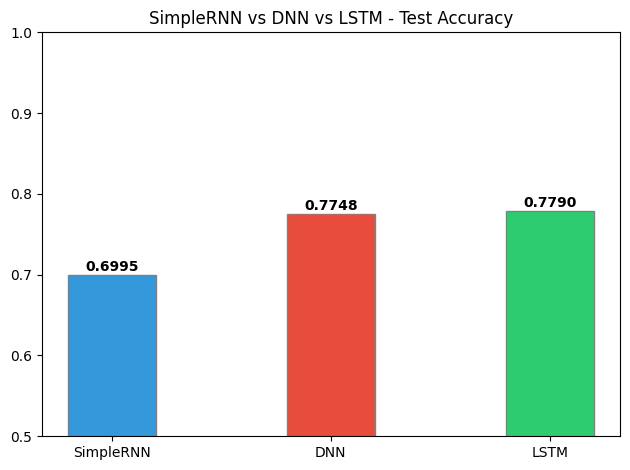

In [58]:
# ── 3개 모델 성능 비교 ──
import matplotlib.pyplot as plt

names  = ['SimpleRNN', 'DNN', 'LSTM']
models = [model_rnn, model_dnn, model_lstm]
accs   = [m.evaluate(X_test_pad, y_test, verbose=0)[1] for m in models]

for n, a in zip(names, accs):
    print(f"{n:12s} Test Accuracy: {a:.4f}")

plt.bar(names, accs, color=['#3498db','#e74c3c','#2ecc71'], edgecolor='gray', width=0.4)
plt.ylim(0.5, 1.0)
plt.title('SimpleRNN vs DNN vs LSTM - Test Accuracy')
for i, v in enumerate(accs):
    plt.text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 실습 - RNN으로 영화평 분류하기 (모형 수정 해보기)
앞의 모형에서 아래의 내용을 바꿔보고 그 결과를 기록해 보세요.
- 기준 모형: `Embedding(10000,32)` + `SimpleRNN(32)` + `optimizer='adam'` + `maxlen=80, padding/truncating='post'`

In [59]:
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
import pandas as pd

# ── 공통 함수 ──
def build_rnn(vocab_size=10000, maxlen=80, stack=False):
    layers = [Embedding(vocab_size, 32, input_length=maxlen)]
    if stack:
        layers.append(SimpleRNN(128, return_sequences=True))
    layers += [SimpleRNN(32), Dense(1, activation='sigmoid')]
    return Sequential(layers)

def run_experiment(model, X_tr, y_tr, X_te, y_te, optimizer='adam'):
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    hist = model.fit(X_tr, y_tr, epochs=5, batch_size=128, validation_split=0.2, verbose=0)
    _, te_acc = model.evaluate(X_te, y_te, verbose=0)
    tr_acc  = hist.history['accuracy'][-1]
    val_acc = hist.history['val_accuracy'][-1]
    return round(tr_acc*100,1), round(val_acc*100,1), round(te_acc*100,1)

results = []

# 기본(Baseline)
tr, val, te = run_experiment(build_rnn(), X_train_pad, y_train, X_test_pad, y_test)
results.append(['기본(Adam)', 'optimizer=adam, words=10000, len=80, post패딩', tr, val, te])
print(f"기본 완료  train:{tr}  val:{val}  test:{te}")

# ① optimizer=sgd
tr, val, te = run_experiment(build_rnn(), X_train_pad, y_train, X_test_pad, y_test, optimizer='sgd')
results.append(['① SGD', 'optimizer=sgd', tr, val, te])
print(f"① 완료  train:{tr}  val:{val}  test:{te}")

# ② num_words=1000
(X_tr2, y_tr2), (X_te2, y_te2) = imdb.load_data(num_words=1000)
X_tr2_pad = pad_sequences(X_tr2, maxlen=80, truncating='post', padding='post')
X_te2_pad = pad_sequences(X_te2, maxlen=80, truncating='post', padding='post')
tr, val, te = run_experiment(build_rnn(vocab_size=1000), X_tr2_pad, y_tr2, X_te2_pad, y_te2)
results.append(['② 단어1000', 'num_words=1000', tr, val, te])
print(f"② 완료  train:{tr}  val:{val}  test:{te}")

# ③ maxlen=200
X_tr3_pad = pad_sequences(X_train, maxlen=200, truncating='post', padding='post')
X_te3_pad = pad_sequences(X_test,  maxlen=200, truncating='post', padding='post')
tr, val, te = run_experiment(build_rnn(maxlen=200), X_tr3_pad, y_train, X_te3_pad, y_test)
results.append(['③ 길이200', 'maxlen=200', tr, val, te])
print(f"③ 완료  train:{tr}  val:{val}  test:{te}")

# ④ padding='pre'
X_tr4_pad = pad_sequences(X_train, maxlen=80, truncating='pre', padding='pre')
X_te4_pad = pad_sequences(X_test,  maxlen=80, truncating='pre', padding='pre')
tr, val, te = run_experiment(build_rnn(), X_tr4_pad, y_train, X_te4_pad, y_test)
results.append(['④ pre패딩', 'padding=pre, truncating=pre', tr, val, te])
print(f"④ 완료  train:{tr}  val:{val}  test:{te}")

# ⑤ RNN 2층
tr, val, te = run_experiment(build_rnn(stack=True), X_train_pad, y_train, X_test_pad, y_test)
results.append(['⑤ RNN추가', 'SimpleRNN(128) 층 추가', tr, val, te])
print(f"⑤ 완료  train:{tr}  val:{val}  test:{te}")

I0000 00:00:1775020284.083406   22555 dot_merger.cc:481] Merging Dots in computation: sequential_23_1_simple_rnn_17_1_while_body_221704_grad_221933_const_0__.17.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1775020287.488048   22555 dot_merger.cc:481] Merging Dots in computation: sequential_23_1_simple_rnn_17_1_while_body_221704_grad_221933_const_0__.17.clone.clone.clone.clone.clone.clone.clone


기본 완료  train:99.0  val:76.2  test:73.8


I0000 00:00:1775020305.437477   22556 dot_merger.cc:481] Merging Dots in computation: sequential_24_1_simple_rnn_18_1_while_body_231035_grad_231264_const_0__.17.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1775020308.624019   22553 dot_merger.cc:481] Merging Dots in computation: sequential_24_1_simple_rnn_18_1_while_body_231035_grad_231264_const_0__.17.clone.clone.clone.clone.clone.clone.clone


① 완료  train:53.0  val:51.4  test:52.3


I0000 00:00:1775020330.726809   22554 dot_merger.cc:481] Merging Dots in computation: sequential_25_1_simple_rnn_19_1_while_body_240642_grad_240871_const_0__.17.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1775020334.101424   22556 dot_merger.cc:481] Merging Dots in computation: sequential_25_1_simple_rnn_19_1_while_body_240642_grad_240871_const_0__.17.clone.clone.clone.clone.clone.clone.clone


...

③ 완료  train:80.6  val:52.0  test:51.8


I0000 00:00:1775020395.389569   22554 dot_merger.cc:481] Merging Dots in computation: sequential_27_1_simple_rnn_21_1_while_body_260320_grad_260549_const_0__.17.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1775020398.599422   22553 dot_merger.cc:481] Merging Dots in computation: sequential_27_1_simple_rnn_21_1_while_body_260320_grad_260549_const_0__.17.clone.clone.clone.clone.clone.clone.clone


④ 완료  train:98.5  val:80.9  test:80.2


I0000 00:00:1775020418.190092   22556 dot_merger.cc:481] Merging Dots in computation: sequential_28_1_simple_rnn_23_1_while_body_271006_grad_271235_const_0__.22.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1775020418.190322   22556 dot_merger.cc:481] Merging Dots in computation: sequential_28_1_simple_rnn_22_1_while_body_270895_grad_271456_const_0__.28.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1775020424.036694   22554 dot_merger.cc:481] Merging Dots in computation: sequential_28_1_simple_rnn_23_1_while_body_271006_grad_271235_const_0__.22.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1775020424.036786   22554 dot_merger.cc:481] Merging Dots in computation: sequential_28_1_simple_rnn_22_1_while_body_270895_grad_271456_const_0__.28.clone.clone.clone.clone.clone.clone.clone


⑤ 완료  train:92.3  val:50.3  test:49.9


In [65]:
# ── 전체 실험 결과 요약 표 ──
import pandas as pd

df = pd.DataFrame(results, columns=['구분', '변경 내용', 'Train Acc(%)', 'Val Acc(%)', 'Test Acc(%)'])

base_test = df.loc[0, 'Test Acc(%)']
df['기본 대비 차이'] = df['Test Acc(%)'].apply(lambda x: f"{x - base_test:+.1f}")
df.loc[0, '기본 대비 차이'] = '+0.0'

df

,구분,변경 내용,Train Acc(%),Val Acc(%),Test Acc(%),기본 대비 차이
0,기본(Adam),"optimizer=adam, words=10000, len=80, post패딩",99.0,76.2,73.8,+0.0
1,① SGD,optimizer=sgd,53.0,51.4,52.3,-21.5
2,② 단어1000,num_words=1000,83.3,76.7,75.5,+1.7
3,③ 길이200,maxlen=200,80.6,52.0,51.8,-22.0
4,④ pre패딩,"padding=pre, truncating=pre",98.5,80.9,80.2,+6.4
5,⑤ RNN추가,SimpleRNN(128) 층 추가,92.3,50.3,49.9,-23.9
